# Study 08 — True-Strength · for the curious

**Is the True Strength Index a *truer* read on momentum than the MACD or the RSI — or the same trade repainted?** No maths needed: we'll just put the three indicators side by side and see whether they ever disagree.

> Verdict up top (from the real 174-name run in `../docs/results.md`): the TSI is **84% reconstructable** from the MACD and RSI, takes the **same position as the MACD 99.4%** of the time, and its equity curve correlates **0.994** with it. Three names, one trade.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (true_strength/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from true_strength import data, oscillators as osc, backtest, collinearity

# Offline synthetic universe: trend/cycle names among random walks. This VALIDATES the
# machinery (oscillators agree where structure is planted). The real verdict (a liquid
# 174-name basket: NONE / MIRAGE / BUSTED) is in ../docs/results.md via verify_real.py.
frames, truth = data.synthetic_universe(seed=0)
structured = {t.ticker for t in truth}
print(f"{len(frames)} names, {len(structured)} with planted momentum structure")


20 names, 8 with planted momentum structure


## 1 · The Claim

The TSI, says its pitch, *double-smooths* momentum to give a cleaner, **truer** strength reading than older oscillators. Let's look at the TSI, the MACD and the RSI on one trending name and ask the obvious question: do they ever tell a different story?

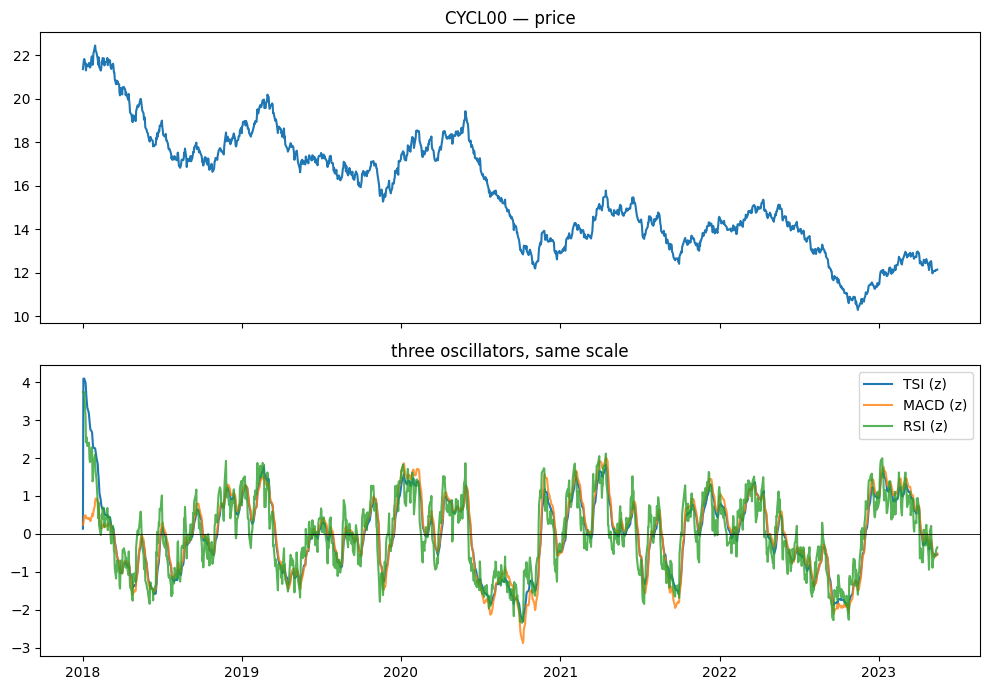

In [2]:
name = sorted(structured)[0]
close = frames[name]['Close']
p = osc.oscillator_panel(close)
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax[0].plot(close.index, close.values); ax[0].set_title(f'{name} — price')
ax[1].plot(p.index, p['z_tsi'], label='TSI (z)')
ax[1].plot(p.index, p['z_macd'], label='MACD (z)', alpha=.8)
ax[1].plot(p.index, p['z_rsi'], label='RSI (z)', alpha=.8)
ax[1].axhline(0, color='k', lw=.6); ax[1].legend(); ax[1].set_title('three oscillators, same scale')
plt.tight_layout(); plt.show()

## 2 · So What?

Traders stack oscillators for *confirmation* — the belief that each says something a little different, so when they agree you have a stronger bet. If the TSI is really a repaint of the MACD, that confirmation is an illusion: you're counting one signal three times and feeling braver for it.

## 3 · How We'd Know

Four escalating questions: do the three move together (correlation)? does the TSI add anything beyond the other two (a spanning test)? do they take the same trade (position agreement)? and is any standalone profit just the reward for being long stocks, not the oscillator? First, a sanity check that the machinery works where we *know* the answer.

In [3]:
rec = collinearity.structure_recall(frames, truth)
print('oscillators agree on structured names:', round(rec['agree_structured'], 3))
print('oscillators agree on noise names:     ', round(rec['agree_noise'], 3))
# They agree more where real momentum structure is planted — the machinery is sound.

oscillators agree on structured names: 0.847
oscillators agree on noise names:      0.816


## 4 · The Teardown

On the structured names, how correlated are the three? And how much of the TSI is just MACD + RSI?

In [4]:
struct = {k: v for k, v in frames.items() if k in structured}
print(collinearity.level_collinearity(struct).round(3).to_string())
inc = collinearity.incremental_information(struct)
print('\nTSI spanned by MACD+RSI — pooled R²:', round(inc['pooled_r2'], 3))

          n_names  median_corr    q25    q75
pair                                        
tsi~macd        8       0.9340 0.9320 0.9500
tsi~rsi         8       0.8940 0.8850 0.8980
macd~rsi        8       0.8640 0.8600 0.8710



TSI spanned by MACD+RSI — pooled R²: 0.912


In [5]:
# Do the TSI and MACD ever take a different position? Plot where each is long.
pos = backtest.positions_by_oscillator(close, rule='zero')
agree = (pos['tsi'] == pos['macd']).mean()
print(f'TSI and MACD take the same long/flat stance {agree:.1%} of days on {name}')

TSI and MACD take the same long/flat stance 98.6% of days on CYCL00


## 5 · The Verdict

On the real 174-name universe (`../docs/results.md`):

- **Signal — distinct? `NONE`.** TSI 84% spanned by MACD+RSI; same position as the MACD 99.4% of days; equity-curve correlation 0.994.
- **Tradability — a distinct edge? `MIRAGE`.** The crossover's 0.61 Sharpe is the reward for being long stocks ~half the time; strip that bias and the TSI's timing Sharpe is 0.05.
- **'Truer' than MACD/RSI? `BUSTED`.** Three names, one trade.

## 6 · Could You Trade It?

You can — and you'll get an ordinary long-biased momentum book that's identical to a MACD crossover (which your platform computes for free). The TSI adds nothing to trade and one more knob to tune.

## 7 · Going Further

Regress the TSI out of MACD+RSI and trade the *residual* — we'd bet its Sharpe is ≈ 0. Or run the same test on the Stochastic, CCI, Williams %R: a little atlas of oscillator redundancy. See the front-page README for the full thread.